# 2次元三角形トラスを有限要素法で解析する

このノートブックは、2次元三角形トラスを有限要素法で解析する教材です。

上から順番にセルを実行することで、解析全体を通して確認できます。
計算は長さ[m]・力[N]・応力[Pa]を基本単位とし、表示時に mm や kN へ換算しています。

解析の流れ:

1. 節点・部材・荷重・支持条件を定義する
2. 要素剛性行列を作り、全体剛性行列 K に組み立てる
3. 支持条件を適用して K u = f を解く
4. 変位から支点反力と部材軸力を求め、理論値と比較する

> ※ 学習用の簡略モデルです。実構造物の設計や安全性の判断には使用しないでください。

> **ℹ️ この記事の対象者**
>
> * Pythonの基本文法を理解している方
> * NumPy、Matplotlibなどを学んだ方
> * Pythonを土木工学の計算に活用してみたい方
> * 構造力学の基本をPythonで扱ってみたい方
> * 前回の「単純梁」の記事を読んだ方

> **⚠️ この記事を読む前に**
>
> * 本記事は筆者個人の学習記録であり、所属する大学や特定の団体の公式見解ではありません。
> * 本記事の内容には十分注意を払っていますが、正確性や完全性を保証するものではありません。
> * 本記事を参考にする場合は、必ずご自身でも教科書、設計基準、最新の公式資料等をご確認ください。
> * 本記事で扱う計算は学習を目的とした簡略化されたモデルです。実務上の設計・安全性の判断には使用しないでください。
> * 実務での構造解析には、関係法令、設計基準、荷重条件、材料特性、施工条件などを含めた専門的な検討が必要です。

これまでの記事一覧はこちらから

[連載一覧]

この連載のGitHubリポジトリはこちら

[GitHubリポジトリ]

今回の記事の内容を気軽に実行したい方は、Google ColabからNotebookを実行できます。

[Google Colab]

# はじめに

前回の記事では、単純支持梁に等分布荷重が作用する問題を題材として、Pythonによる構造力学の計算を行いました。

単純梁では、

```text
L, q, E, I
    ↓
理論式
    ↓
V(x), M(x), w(x)
```

という流れで、梁のせん断力、曲げモーメント、たわみを計算しました。

今回は、そこからさらに一歩進みます。

今回扱うのは **トラス構造** です。

トラスは、橋梁、屋根構造などさまざまな構造物で利用される代表的な構造形式です。

トラスを構成する部材は、理想化すると主に軸方向の力を受ける部材として扱うことができます。

今回は2次元トラスを題材として、

* 節点と部材の定義
* 部材の長さ・方向の計算
* 要素剛性行列
* 座標変換
* 全体剛性行列の組立
* 境界条件の設定
* `Ku=f` の求解
* 節点変位の計算
* 支点反力の計算
* 部材軸力の計算
* 変形図の可視化
* 理論値との比較

までをPythonで実装してみます。

今回の解析では、これまで学んできたNumPyが非常に重要になります。

特に、

```text
部材の剛性
    ↓
要素剛性行列
    ↓
全体剛性行列 K
    ↓
Ku = f
    ↓
節点変位 u
    ↓
部材軸力
```

という流れをPythonで実際に確認していきます。

これは、今後より複雑な構造解析をPythonで扱うための重要な考え方です。

# 1. 今回扱うトラス

今回は、最も基本的な2次元三角形トラスを考えます。

```text
             C
            / \
           /   \
          /     \
         /       \
        A---------B
```

節点A、B、Cの3つの節点と、

```text
AB
AC
BC
```

の3本の部材から構成されるトラスです。

節点Cに下向きの荷重を作用させます。

```text
              C
              ↓ P
             / \
            /   \
           /     \
          /       \
         A---------B
         ▲         ○
```

ここでは、Aをピン支持、Bをローラー支持とします。

したがって、支持条件は、

```text
A：
x方向変位 = 0
y方向変位 = 0

B：
y方向変位 = 0
```

とします。

節点Cには下向きの荷重を作用させます。

今回の条件を表にまとめると次のようになります。

| 項目        |           値 |
| --------- | ----------: |
| A座標       |    (0, 0) m |
| B座標       |    (4, 0) m |
| C座標       |    (2, 3) m |
| ヤング係数 `E` |     200 GPa |
| 断面積 `A`   | 1.0×10⁻³ m² |
| 節点Cの荷重    |   10 kN 下向き |

ここで注意したいのが、今回の `A` です。

節点名にもAを使用していますが、断面積にも一般的に `A` が使用されます。

コードでは混乱を避けるため、断面積を `A_cs` とします。

# 2. トラス構造の仮定

実際のトラス構造は複雑ですが、今回は学習を目的としてモデルを簡略化します。

主な仮定は次のとおりです。

* 2次元構造として扱う
* 部材は直線部材とする
* 節点はピン接合とする
* 部材は軸方向力のみを負担する
* 部材の曲げ剛性は考慮しない
* 材料は線形弾性体とする
* 変形は小さい
* 各部材のヤング係数は一定とする
* 各部材の断面積は一定とする

このような仮定を置いた構造を、一般に **2次元トラス要素** として扱います。

今回の解析では、部材の伸び縮みから節点の変位を求めます。

つまり、梁のように、

```text
曲げ
せん断
たわみ
```

を直接扱うのではなく、

```text
軸方向の伸縮
```

を中心に考えます。

# 3. 節点と部材をPythonで定義する

まず、節点の座標を定義します。

In [8]:
import numpy as np

# 節点座標
nodes = np.array([
    [0.0, 0.0],  # A
    [4.0, 0.0],  # B
    [2.0, 3.0],  # C
])

print(nodes)

[[0. 0.]
 [4. 0.]
 [2. 3.]]


この配列では、

```text
nodes[0] → A
nodes[1] → B
nodes[2] → C
```

となっています。

例えば、節点Cの座標は、

In [9]:
print(nodes[2])

[2. 3.]


次に、部材を定義します。

ここでは節点番号を使って、

```text
0 → A
1 → B
2 → C
```

として定義します。

In [10]:
members = [
    (0, 1),  # A-B
    (0, 2),  # A-C
    (1, 2),  # B-C
]

# 4. トラスをMatplotlibで描いてみる

まず、今回の解析対象を可視化してみましょう。

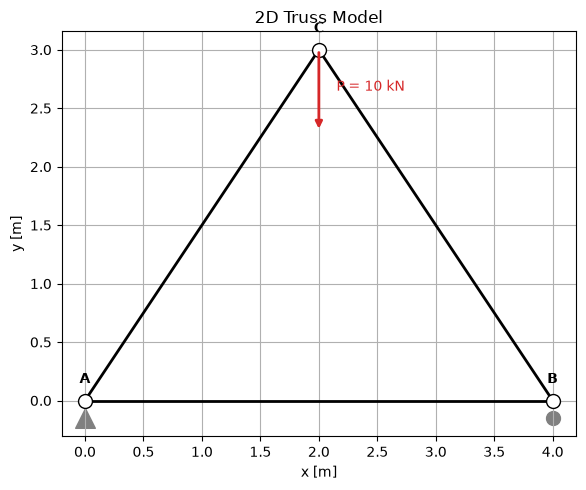

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# 部材
for i, j in members:
    x = [nodes[i, 0], nodes[j, 0]]
    y = [nodes[i, 1], nodes[j, 1]]
    ax.plot(x, y, color="black", linewidth=2)

# 節点
ax.scatter(
    nodes[:, 0],
    nodes[:, 1],
    color="white",
    edgecolors="black",
    s=100,
    zorder=3,
)

# 節点ラベル
labels = ["A", "B", "C"]

for i, label in enumerate(labels):
    ax.text(
        nodes[i, 0],
        nodes[i, 1] + 0.15,
        label,
        ha="center",
        fontweight="bold",
    )

# 支点A
ax.scatter(
    nodes[0, 0],
    nodes[0, 1] - 0.15,
    marker="^",
    s=200,
    color="gray",
)

# 支点B
ax.scatter(
    nodes[1, 0],
    nodes[1, 1] - 0.15,
    marker="o",
    s=100,
    color="gray",
)

# 荷重
ax.annotate(
    "",
    xy=(nodes[2, 0], nodes[2, 1] - 0.7),
    xytext=(nodes[2, 0], nodes[2, 1]),
    arrowprops=dict(
        arrowstyle="-|>",
        color="tab:red",
        lw=2,
    ),
)

ax.text(
    nodes[2, 0] + 0.15,
    nodes[2, 1] - 0.35,
    "P = 10 kN",
    color="tab:red",
)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("2D Truss Model")
ax.grid(True)

plt.tight_layout()
plt.show()

# 5. 2次元トラスの自由度

ここからが今回の解析の中心です。

2次元トラスでは、各節点に、

```text
x方向変位
y方向変位
```

の2つの自由度があります。

今回の節点は3つなので、自由度の総数は、

$$3\times2=6$$

です。

自由度を次のように番号付けします。

```text
節点A
u0 → x方向
u1 → y方向

節点B
u2 → x方向
u3 → y方向

節点C
u4 → x方向
u5 → y方向
```

したがって、節点変位ベクトルは、

$$\mathbf{u} = \begin{bmatrix} u_0 \\ u_1 \\ u_2 \\ u_3 \\ u_4 \\ u_5 \end{bmatrix}$$

となります。

In [12]:
# 2次元トラスでは、各節点にx方向・y方向の2自由度があります。
# したがって、節点数 × 2 が全体の自由度数です。
ndof = 2 * len(nodes)

# 変位ベクトルを、全自由度がまだ変位していない状態で初期化します。
u = np.zeros(ndof)

print(u)

[0. 0. 0. 0. 0. 0.]


# 6. 荷重ベクトルを作る

次に荷重を定義します。

今回は節点Cに10 kNの下向き荷重を作用させます。

SI単位系を使用するため、

```text
10 kN = 10000 N
```

です。

荷重ベクトルは、

$$\mathbf{f} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ -10000 \end{bmatrix}$$

となります。

In [13]:
# 荷重はNで入力します（10 kN = 10,000 N）。
P = 10_000.0

# 荷重ベクトルも自由度の並び [Aのx, Aのy, Bのx, ...] に合わせます。
f = np.zeros(ndof)

# 節点Cのy方向自由度は5番目です。下向きなので符号はマイナスです。
f[5] = -P

print(f)

[     0.      0.      0.      0.      0. -10000.]


# 7. 部材の長さを求める

次に、それぞれの部材について長さを求めます。

2点、

```text
(xi, yi)
(xj, yj)
```

を結ぶ部材の長さは、

$$L_e = \sqrt{(x_j-x_i)^2 + (y_j-y_i)^2}$$

です。

In [14]:
def member_length(nodes, i, j):
    """節点iと節点jを結ぶ部材の長さ[m]を返します。"""
    dx = nodes[j, 0] - nodes[i, 0]
    dy = nodes[j, 1] - nodes[i, 1]

    return np.hypot(dx, dy)


for i, j in members:
    L = member_length(nodes, i, j)
    print(f"{i}-{j}: {L:.3f} m")

0-1: 4.000 m
0-2: 3.606 m
1-2: 3.606 m


# 8. 部材の方向を表す

トラス部材は水平・鉛直とは限りません。

例えばA-C部材には、

```text
x方向成分
y方向成分
```

があります。

そこで、部材の方向を表すために方向余弦を使用します。

部材の長さを `L_e` とすると、

$$c = \frac{x_j-x_i}{L_e}$$

$$s = \frac{y_j-y_i}{L_e}$$

です。ここで、

```text
c = cos θ
s = sin θ
```

に対応します。

In [15]:
def direction_cosines(nodes, i, j):
    """部材の方向を表す cos(theta), sin(theta) を返します。"""
    dx = nodes[j, 0] - nodes[i, 0]
    dy = nodes[j, 1] - nodes[i, 1]

    L = np.hypot(dx, dy)

    c = dx / L
    s = dy / L

    return c, s


c, s = direction_cosines(nodes, 0, 2)

print(f"c = {c:.6f}")
print(f"s = {s:.6f}")

c = 0.554700
s = 0.832050


# 9. トラス要素の剛性

ここで、構造解析で重要になる概念が **剛性** です。

ばねをイメージすると分かりやすいでしょう。

ばねでは、

$$F = k\delta$$

という関係があります。部材の軸方向剛性は、

$$\frac{EA}{L_e}$$

です。

ここで、

* `E`：ヤング係数
* `A`：断面積
* `L_e`：部材長

です。

# 10. 要素剛性行列

2次元トラス部材について、全体座標系で表した要素剛性行列は、

$$\mathbf{k}^{(e)} = \frac{EA}{L_e} \begin{bmatrix} c^2 & cs & -c^2 & -cs\\ cs & s^2 & -cs & -s^2\\ -c^2 & -cs & c^2 & cs\\ -cs & -s^2 & cs & s^2 \end{bmatrix}$$

となります。

In [16]:
def truss_element_stiffness(E, A, nodes, i, j):
    """2次元トラス部材の4×4要素剛性行列を作成します。

    Eはヤング係数[Pa]、Aは断面積[m^2]です。
    """
    xi, yi = nodes[i]
    xj, yj = nodes[j]

    dx = xj - xi
    dy = yj - yi

    L = np.hypot(dx, dy)

    c = dx / L
    s = dy / L

    factor = E * A / L

    k = factor * np.array([
        [ c*c,  c*s, -c*c, -c*s],
        [ c*s,  s*s, -c*s, -s*s],
        [-c*c, -c*s,  c*c,  c*s],
        [-c*s, -s*s,  c*s,  s*s],
    ])

    return k

# 11. 実際に要素剛性行列を確認する

In [17]:
E = 200e9
A_cs = 1.0e-3

k_ac = truss_element_stiffness(
    E,
    A_cs,
    nodes,
    0,
    2,
)

print(k_ac)

[[ 17067698.34539166  25601547.5180875  -17067698.34539166
  -25601547.5180875 ]
 [ 25601547.5180875   38402321.27713125 -25601547.5180875
  -38402321.27713125]
 [-17067698.34539166 -25601547.5180875   17067698.34539166
   25601547.5180875 ]
 [-25601547.5180875  -38402321.27713125  25601547.5180875
   38402321.27713125]]


# 12〜14. 全体剛性行列を組み立てる
各部材の要素剛性行列を、対応する全体自由度へ足し合わせます。

In [18]:
def element_dofs(i, j):
    """部材(i, j)に対応する全体自由度番号を返します。"""
    return [
        2 * i,
        2 * i + 1,
        2 * j,
        2 * j + 1,
    ]


# 全体剛性行列Kは、全自由度同士の関係を表す行列です。
K = np.zeros((ndof, ndof))

for i, j in members:
    k = truss_element_stiffness(
        E,
        A_cs,
        nodes,
        i,
        j,
    )

    # 要素行列の4自由度を、全体行列の該当位置へ加算します。
    dofs = element_dofs(i, j)
    K[np.ix_(dofs, dofs)] += k

print(K)

[[ 67067698.34539166  25601547.5180875  -50000000.
          0.         -17067698.34539166 -25601547.5180875 ]
 [ 25601547.5180875   38402321.27713125         0.
          0.         -25601547.5180875  -38402321.27713125]
 [-50000000.                 0.          67067698.34539166
  -25601547.5180875  -17067698.34539166  25601547.5180875 ]
 [        0.                 0.         -25601547.5180875
   38402321.27713125  25601547.5180875  -38402321.27713125]
 [-17067698.34539166 -25601547.5180875  -17067698.34539166
   25601547.5180875   34135396.69078333         0.        ]
 [-25601547.5180875  -38402321.27713125  25601547.5180875
  -38402321.27713125         0.          76804642.5542625 ]]


# 15. 境界条件を設定する

支持条件：

```text
A：ux = 0, uy = 0 (自由度 0, 1)
B：uy = 0 (自由度 3)
```

In [19]:
# Aはx・y方向を固定し、Bはy方向だけを固定します。
# 固定自由度を除いた部分行列 K_ff だけを解くことで、既知の変位0を反映します。
fixed_dofs = [0, 1, 3]

all_dofs = np.arange(ndof)

free_dofs = np.setdiff1d(
    all_dofs,
    fixed_dofs,
)

print("固定自由度:", fixed_dofs)
print("自由自由度:", free_dofs)

固定自由度: [0, 1, 3]
自由自由度: [2 4 5]


# 16. `Ku=f` を解く

In [20]:
# 未知変位に対応する部分行列と荷重だけを取り出して解きます。
K_ff = K[np.ix_(free_dofs, free_dofs)]
f_f = f[free_dofs]

u_free = np.linalg.solve(
    K_ff,
    f_f,
)

u = np.zeros(ndof)
u[free_dofs] = u_free

print(u)

[ 0.00000000e+00  0.00000000e+00  6.66666667e-05  0.00000000e+00
  3.33333333e-05 -1.52422685e-04]


# 17. 解析全体を1つのコードにまとめる
# 18. 節点変位を確認する

In [21]:
# まとめコードとして節点変位をミリメートル単位で表示
print("節点変位")

for i in range(len(nodes)):
    ux = u[2 * i]
    uy = u[2 * i + 1]

    print(
        f"節点{i}: "
        f"ux = {ux * 1000:.6f} mm, "
        f"uy = {uy * 1000:.6f} mm"
    )

節点変位
節点0: ux = 0.000000 mm, uy = 0.000000 mm
節点1: ux = 0.066667 mm, uy = 0.000000 mm
節点2: ux = 0.033333 mm, uy = -0.152423 mm


# 19. 支点反力を求める

$$\mathbf{r} = \mathbf{K}\mathbf{u} - \mathbf{f}$$

In [22]:
reactions = K @ u - f

print("支点反力")

for dof in fixed_dofs:
    print(
        f"自由度 {dof}: "
        f"{reactions[dof] / 1000:.3f} kN"
    )

支点反力
自由度 0: 0.000 kN
自由度 1: 5.000 kN
自由度 3: 5.000 kN


# 20. 部材軸力を求める
# 21. なぜ斜材が圧縮になるのか

部材軸方向の変形：

$$\delta_e = -c u_i - s v_i + c u_j + s v_j$$

部材軸力：

$$N_e = \frac{EA}{L_e} \delta_e$$

In [23]:
def member_axial_force(E, A, nodes, i, j, u):
    """部材の伸びから軸力[N]を計算します。

    正の値は引張、負の値は圧縮を表します。
    """
    xi, yi = nodes[i]
    xj, yj = nodes[j]

    dx = xj - xi
    dy = yj - yi

    L = np.hypot(dx, dy)

    c = dx / L
    s = dy / L

    dofs = element_dofs(i, j)

    ue = u[dofs]

    extension = (
        -c * ue[0]
        -s * ue[1]
        +c * ue[2]
        +s * ue[3]
    )

    N = E * A / L * extension

    return N


print("部材軸力")
for i, j in members:
    N = member_axial_force(
        E,
        A_cs,
        nodes,
        i,
        j,
        u,
    )

    print(
        f"{i}-{j}: "
        f"{N / 1000:.3f} kN"
    )

部材軸力
0-1: 3.333 kN
0-2: -6.009 kN
1-2: -6.009 kN


# 22. 変形を可視化する

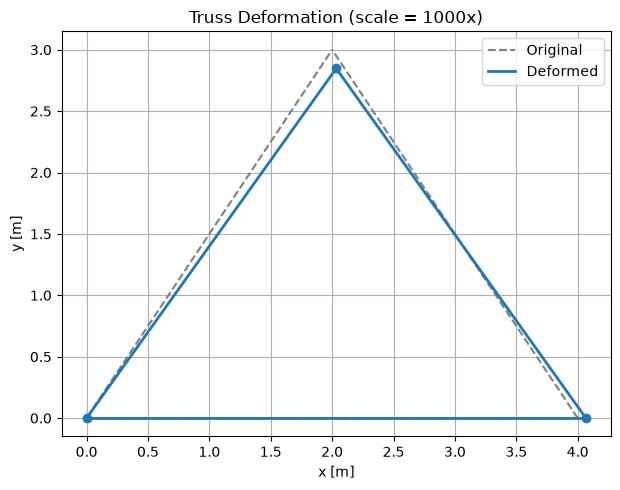

In [24]:
# 実際の変位は非常に小さいため、図では1000倍に拡大して表示します。
# scaleは表示用であり、計算した変位uそのものは変更しません。
scale = 1000

deformed_nodes = nodes.copy()

for i in range(len(nodes)):
    deformed_nodes[i, 0] += scale * u[2 * i]
    deformed_nodes[i, 1] += scale * u[2 * i + 1]

fig, ax = plt.subplots(figsize=(7, 5))

# 元のトラス
for i, j in members:
    ax.plot(
        [nodes[i, 0], nodes[j, 0]],
        [nodes[i, 1], nodes[j, 1]],
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label="Original" if (i, j) == members[0] else None,
    )

# 変形後
for i, j in members:
    ax.plot(
        [deformed_nodes[i, 0], deformed_nodes[j, 0]],
        [deformed_nodes[i, 1], deformed_nodes[j, 1]],
        color="tab:blue",
        linewidth=2,
        label="Deformed" if (i, j) == members[0] else None,
    )

# 変形後の節点
ax.scatter(
    deformed_nodes[:, 0],
    deformed_nodes[:, 1],
    color="tab:blue",
    zorder=3,
)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(
    f"Truss Deformation "
    f"(scale = {scale}x)"
)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# 23. 部材軸力を色で表示する

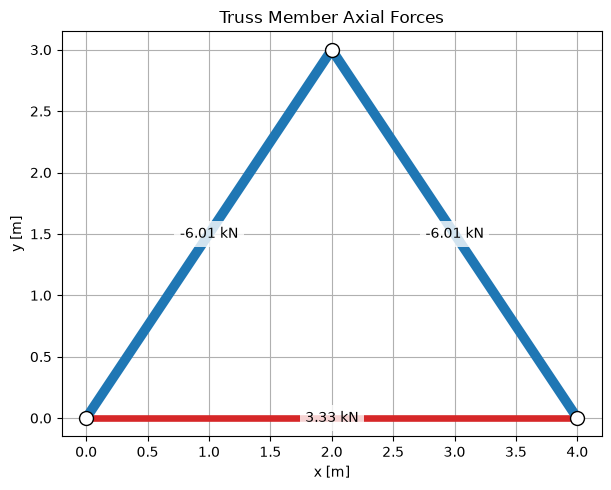

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

forces = []

for i, j in members:
    N = member_axial_force(
        E,
        A_cs,
        nodes,
        i,
        j,
        u,
    )
    forces.append(N)

max_force = max(
    abs(N) for N in forces
)

for (i, j), N in zip(members, forces):
    if N >= 0:
        color = "tab:red"
    else:
        color = "tab:blue"

    linewidth = (
        2
        + 5 * abs(N) / max_force
    )

    ax.plot(
        [nodes[i, 0], nodes[j, 0]],
        [nodes[i, 1], nodes[j, 1]],
        color=color,
        linewidth=linewidth,
    )

    x_mid = (
        nodes[i, 0] + nodes[j, 0]
    ) / 2

    y_mid = (
        nodes[i, 1] + nodes[j, 1]
    ) / 2

    ax.text(
        x_mid,
        y_mid,
        f"{N / 1000:.2f} kN",
        ha="center",
        va="center",
        bbox=dict(
            fc="white",
            ec="none",
            alpha=0.8,
        ),
    )

ax.scatter(
    nodes[:, 0],
    nodes[:, 1],
    color="white",
    edgecolors="black",
    s=100,
    zorder=3,
)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Truss Member Axial Forces")
ax.grid(True)

plt.tight_layout()
plt.show()

# 24. 理論値と比較する
# 25. Pythonで理論値との誤差を確認する

In [26]:
# 理論値
N_diagonal_theory = (
    -P * np.sqrt(13) / 6
)

N_bottom_theory = (
    P / 3
)

print(
    "斜材の理論値:",
    f"{N_diagonal_theory / 1000:.6f} kN"
)

print(
    "下弦材の理論値:",
    f"{N_bottom_theory / 1000:.6f} kN"
)

computed_forces = []

for i, j in members:
    N = member_axial_force(
        E,
        A_cs,
        nodes,
        i,
        j,
        u,
    )
    computed_forces.append(N)

print(
    "AB:",
    np.isclose(
        computed_forces[0],
        N_bottom_theory,
        rtol=1e-6,
    ),
)

print(
    "AC:",
    np.isclose(
        computed_forces[1],
        N_diagonal_theory,
        rtol=1e-6,
    ),
)

print(
    "BC:",
    np.isclose(
        computed_forces[2],
        N_diagonal_theory,
        rtol=1e-6,
    ),
)

斜材の理論値: -6.009252 kN
下弦材の理論値: 3.333333 kN
AB: True
AC: True
BC: True


# 26. 力のつり合いも確認する

In [27]:
RA_y = reactions[1]
RB_y = reactions[3]

vertical_balance = (
    RA_y
    + RB_y
    - P
)

print(
    f"鉛直方向のつり合い: "
    f"{vertical_balance:.6e} N"
)

print(
    "つり合いが成立:",
    np.isclose(
        vertical_balance,
        0.0,
        atol=1e-8,
    ),
)

鉛直方向のつり合い: 0.000000e+00 N
つり合いが成立: True


# 27. 剛性を変えてみる

In [28]:
areas = np.array([
    0.5e-3,
    1.0e-3,
    2.0e-3,
    4.0e-3,
])

for A_test in areas:
    K_test = np.zeros((ndof, ndof))

    for i, j in members:
        k = truss_element_stiffness(
            E,
            A_test,
            nodes,
            i,
            j,
        )

        dofs = element_dofs(i, j)

        K_test[np.ix_(dofs, dofs)] += k

    K_ff = K_test[
        np.ix_(free_dofs, free_dofs)
    ]

    u_test = np.zeros(ndof)

    u_test[free_dofs] = np.linalg.solve(
        K_ff,
        f[free_dofs],
    )

    displacement = abs(u_test[5])

    print(
        f"A = {A_test:.2e} m² : "
        f"|uy(C)| = {displacement * 1000:.6f} mm"
    )

A = 5.00e-04 m² : |uy(C)| = 0.304845 mm
A = 1.00e-03 m² : |uy(C)| = 0.152423 mm
A = 2.00e-03 m² : |uy(C)| = 0.076211 mm
A = 4.00e-03 m² : |uy(C)| = 0.038106 mm


# 28. ヤング係数を変えてみる

In [29]:
youngs_moduli = np.array([
    100e9,
    150e9,
    200e9,
    250e9,
])

for E_test in youngs_moduli:
    K_test = np.zeros((ndof, ndof))

    for i, j in members:
        k = truss_element_stiffness(
            E_test,
            A_cs,
            nodes,
            i,
            j,
        )

        dofs = element_dofs(i, j)

        K_test[np.ix_(dofs, dofs)] += k

    K_ff = K_test[
        np.ix_(free_dofs, free_dofs)
    ]

    u_test = np.zeros(ndof)

    u_test[free_dofs] = np.linalg.solve(
        K_ff,
        f[free_dofs],
    )

    displacement = abs(u_test[5])

    print(
        f"E = {E_test / 1e9:.0f} GPa : "
        f"|uy(C)| = {displacement * 1000:.6f} mm"
    )

E = 100 GPa : |uy(C)| = 0.304845 mm
E = 150 GPa : |uy(C)| = 0.203230 mm
E = 200 GPa : |uy(C)| = 0.152423 mm
E = 250 GPa : |uy(C)| = 0.121938 mm


# 29. 荷重を変えてみる

In [30]:
# 荷重以外の条件（E、断面積、支持条件）は基準モデルに戻します。
# 直前の「ヤング係数を変えてみる」で K_ff が上書きされているため、
# ここでは基準値 E=200 GPa の全体剛性行列 K から作り直します。
K_ff = K[np.ix_(free_dofs, free_dofs)]

loads = np.array([
    5_000,
    10_000,
    20_000,
    40_000,
])

for P_test in loads:
    f_test = np.zeros(ndof)
    f_test[5] = -P_test

    u_test = np.zeros(ndof)

    u_test[free_dofs] = np.linalg.solve(
        K_ff,
        f_test[free_dofs],
    )

    print(
        f"P = {P_test / 1000:.1f} kN : "
        f"uy(C) = {u_test[5] * 1000:.6f} mm"
    )

P = 5.0 kN : uy(C) = -0.076211 mm
P = 10.0 kN : uy(C) = -0.152423 mm
P = 20.0 kN : uy(C) = -0.304845 mm
P = 40.0 kN : uy(C) = -0.609691 mm


# 30. 計算処理を関数にまとめる

In [31]:
def solve_truss(
    nodes,
    members,
    E,
    A,
    loads,
    fixed_dofs,
):
    """2次元トラスの線形静解析を行います。

    部材剛性を全体剛性行列へ組み立て、拘束されていない自由度だけを
    取り出して連立方程式を解きます。

    Parameters
    ----------
    nodes : numpy.ndarray
        節点座標 [m]
    members : list of tuple
        部材を構成する節点番号
    E : float
        ヤング係数 [Pa]
    A : float
        部材断面積 [m^2]
    loads : numpy.ndarray
        荷重ベクトル [N]
    fixed_dofs : list
        拘束する自由度番号

    Returns
    -------
    K : numpy.ndarray
        全体剛性行列
    u : numpy.ndarray
        節点変位ベクトル [m]
    reactions : numpy.ndarray
        支点反力ベクトル [N]
    """

    ndof = 2 * len(nodes)

    K = np.zeros((ndof, ndof))

    for i, j in members:
        k = truss_element_stiffness(
            E,
            A,
            nodes,
            i,
            j,
        )

        dofs = element_dofs(i, j)

        K[np.ix_(dofs, dofs)] += k

    all_dofs = np.arange(ndof)

    free_dofs = np.setdiff1d(
        all_dofs,
        fixed_dofs,
    )

    K_ff = K[
        np.ix_(free_dofs, free_dofs)
    ]

    f_f = loads[free_dofs]

    u = np.zeros(ndof)

    u[free_dofs] = np.linalg.solve(
        K_ff,
        f_f,
    )

    reactions = K @ u - loads

    return K, u, reactions

# 31. 関数を使って解析する

In [32]:
f = np.zeros(ndof)
f[5] = -10_000.0

K, u, reactions = solve_truss(
    nodes=nodes,
    members=members,
    E=200e9,
    A=1.0e-3,
    loads=f,
    fixed_dofs=[0, 1, 3],
)

print(
    f"Cのx方向変位: "
    f"{u[4] * 1000:.6f} mm"
)

print(
    f"Cのy方向変位: "
    f"{u[5] * 1000:.6f} mm"
)

Cのx方向変位: 0.033333 mm
Cのy方向変位: -0.152423 mm


# 32. 今回の解析の流れ
# 33. 単純梁解析との違い
# 34. 「有限要素法」の考え方
# 35. NumPyが構造解析に向いている理由
# 36. モデルを大きくしてみる
# 37. 複数の条件を自動計算する

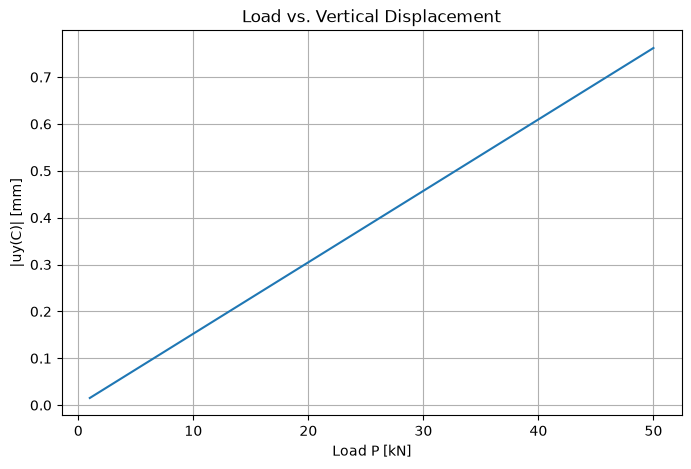

In [33]:
loads = np.linspace(
    1_000,
    50_000,
    50,
)

displacements = []

for P_test in loads:
    f_test = np.zeros(ndof)
    f_test[5] = -P_test

    _, u_test, _ = solve_truss(
        nodes=nodes,
        members=members,
        E=E,
        A=A_cs,
        loads=f_test,
        fixed_dofs=[0, 1, 3],
    )

    displacements.append(
        abs(u_test[5])
    )

displacements = np.array(
    displacements
)

plt.figure(figsize=(8, 5))

plt.plot(
    loads / 1000,
    displacements * 1000,
)

plt.xlabel("Load P [kN]")
plt.ylabel("|uy(C)| [mm]")
plt.title(
    "Load vs. Vertical Displacement"
)

plt.grid(True)
plt.show()

# 38. 構造解析をデータ処理につなげる

In [34]:
import pandas as pd

results = []

for P_test in [
    5_000,
    10_000,
    20_000,
    40_000,
]:
    f_test = np.zeros(ndof)
    f_test[5] = -P_test

    _, u_test, _ = solve_truss(
        nodes=nodes,
        members=members,
        E=E,
        A=A_cs,
        loads=f_test,
        fixed_dofs=[0, 1, 3],
    )

    results.append({
        "P [kN]": P_test / 1000,
        "ux_C [mm]": u_test[4] * 1000,
        "uy_C [mm]": u_test[5] * 1000,
    })

df = pd.DataFrame(results)

print(df)

   P [kN]  ux_C [mm]  uy_C [mm]
0     5.0   0.016667  -0.076211
1    10.0   0.033333  -0.152423
2    20.0   0.066667  -0.304845
3    40.0   0.133333  -0.609691


# 39. 今回の解析モデルで重要なこと

今回のプログラムでは、非常に重要な考え方をいくつか扱いました。

まず、

```text
構造物
```

を、

```text
節点
+
部材
```

というデータに変換しました。

次に、各部材について、

```text
長さ
方向
剛性
```

を計算しました。

そして、それらを、

```text
全体剛性行列 K
```

へ組み立てました。

最後に、

$$\mathbf{K}\mathbf{u} = \mathbf{f}$$

を解くことで、節点変位を求め、さらにその変位から支点反力や部材軸力を計算しました。

# 40. 今回学んだこと
# 41. 次回以降につながる考え方
# まとめ

## 参考

* 﨑元達郎（著）『構造力学［第2版・新装補訂版］上 静定編』森北出版
* Python Documentation
* NumPy Documentation
* Matplotlib Documentation
* 本連載のGitHubリポジトリ